# Dimensionality reduction

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec


from pca_wrapper import *
from deeptime.decomposition import TICA
import plotting_utils as pu

data_folder = "../data/"

---
### Loading trajectiories

In [5]:
# set 1: distances
distances = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float)
print("Data shape", distances.shape) # [nm] nanometers
print("Data size (MB)", distances.nbytes / (10**6))

# set 2: dihedrals
dihedrals = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
print("Data shape", dihedrals.shape) # [radians] 
print("Data size (MB)", dihedrals.nbytes / (10**6))

Data shape (1526041, 42)
Data size (MB) 512.749776
Data shape (1526041, 66)
Data size (MB) 805.749648


In [7]:
total_time_micros = 300
time_step_micros =  total_time_micros / distances.shape[0]
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


---
### Exploring tICA at different lagtimes

In [10]:
X = dihedrals
n_tics = 7
lagtime_array = [10, 100, 1000, 100000] 
lagtime_microseconds = [lag * time_step_micros for lag in lagtime_array]
print("Lag times (microseconds)", lagtime_microseconds) # [2, 20, 200, 20000] microseconds
print("Lag times (nanoseconds)", [lag * time_step_micros * 10**3 for lag in lagtime_array]) # [0.2, 2, 20, 2000] nanoseconds

Lag times (microseconds) [0.001965871165977847, 0.019658711659778474, 0.19658711659778472, 19.658711659778472]
Lag times (nanoseconds) [1.965871165977847, 19.658711659778472, 196.58711659778473, 19658.711659778473]


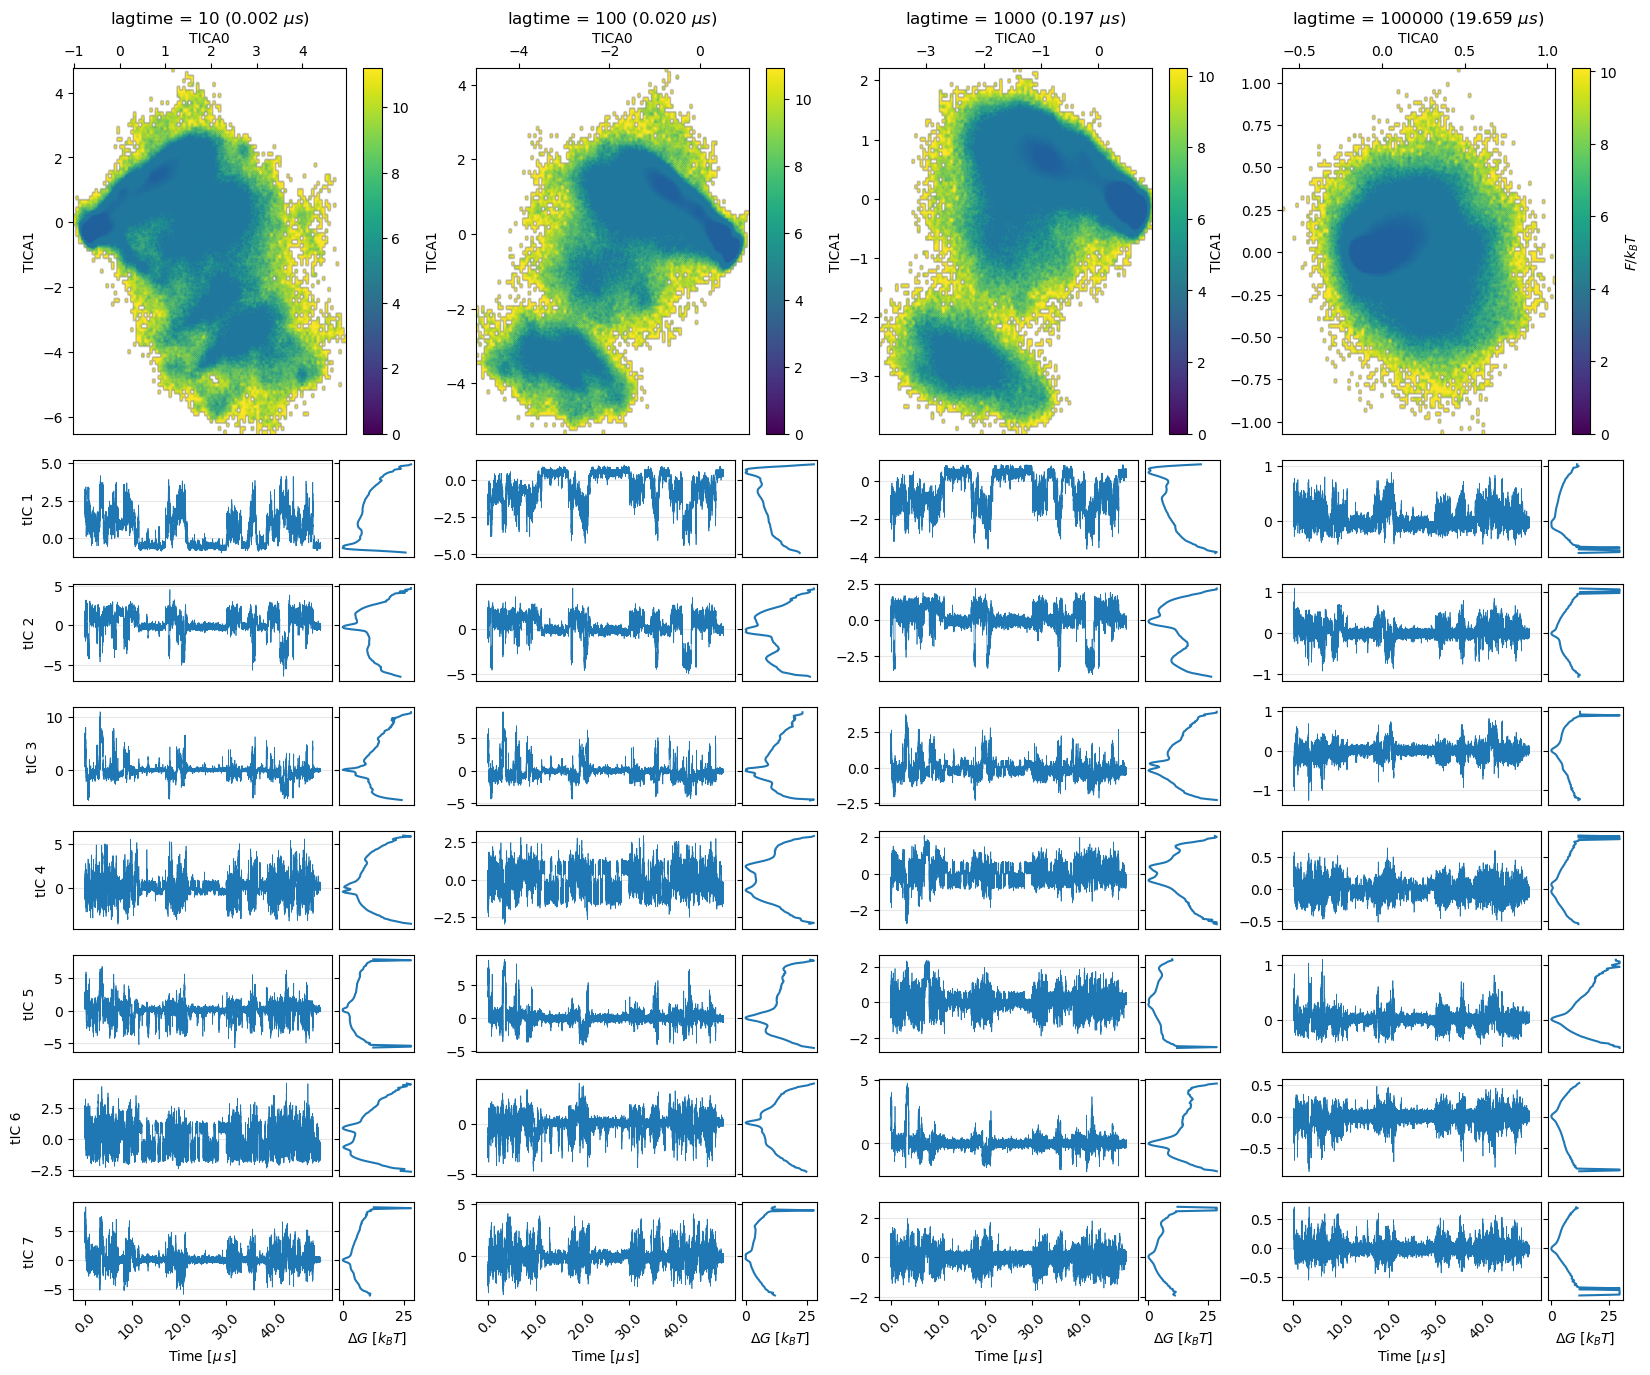

In [11]:
###########################################
# ----------- Plot specifics --------------

n_microseconds_show = 50
tickevery = 10
n_show = n_microseconds_show * one_microsecond_in_frames
n_lags = len(lagtime_array)

fig = plt.figure(figsize=(5* n_lags, 16))

gs = GridSpec(
    nrows=n_tics + 1,
    ncols=n_lags,
    figure=fig,
    height_ratios=[3] + [0.8] * n_tics,
    hspace=0.2,
    wspace=0.18
)

axes = np.empty((n_tics + 1, n_lags), dtype=object)

for i in range(n_tics + 1):
    for j in range(n_lags):
        axes[i, j] = fig.add_subplot(gs[i, j])   
###########################################


for lagtime in lagtime_array:
    # fit tica
    #############################################
    ticamodel = TICA(lagtime=lagtime, dim=n_tics)
    ticamodel.fit(X)
    tica_traj = ticamodel.transform(X)
    #############################################
    
    # Plot
    if lagtime == lagtime_array[-1]:
        colorbarlabel = r"$F/k_B T$"
    else:        
        colorbarlabel = None
    pu.plot_free_energy_projection(tica_traj, 0, 1, ax = axes[0, lagtime_array.index(lagtime)], axlabel = "TICA", colorbarlabel = colorbarlabel, axtitle = rf"lagtime = {lagtime} ({lagtime_microseconds[lagtime_array.index(lagtime)]:.3f} $\mu s$)")

    for component in range(n_tics):

        j = lagtime_array.index(lagtime)
        ax = axes[1 + component, j]
        x = tica_traj[:n_show, component]
        ax.set_xticks(np.arange(0, n_show, tickevery*one_microsecond_in_frames))
        ax.set_xticklabels(np.arange(0, n_show/one_microsecond_in_frames, tickevery), rotation=45)
        ax.plot(x, lw=0.5)
        if lagtime == lagtime_array[0]:
            ax.set_ylabel(f"tIC {component + 1}")
        else:
            ax.set_ylabel("")
        ax.tick_params(axis="x", labelrotation=45)
        ax.grid(axis="y", alpha=0.3)
        ax_fe = pu.add_1d_free_energy_axis(
            ax=ax,
            x=tica_traj[:, component], #all trajectory for free energy
            bins=100,
            color="C0")
        if component < n_tics - 1:
            ax.set_xticks([])
            ax.set_xlabel("")
            ax_fe.set_xticks([])

        else:
            ax.set_xlabel(r"Time [$\mu\, s$]")
            ax_fe.set_xlabel(r"$\Delta G$ [$k_B T$]")

---
## Exploring PCA: dihedrals vs distances

In [ ]:
#def gap_diagnostic(eigenvalues):
#    sorted_eigenvalues = sorted(eigenvalues, reverse=True)
#    gaps = [sorted_eigenvalues[i] - sorted_eigenvalues[i + 1] for i in range(len(sorted_eigenvalues) - 1)]
#    diff_gaps = [(gaps[i] - gaps[i + 1])/gaps[i] for i in range(len(gaps) - 1) if gaps[i] != 0]
#    return gaps, diff_gaps

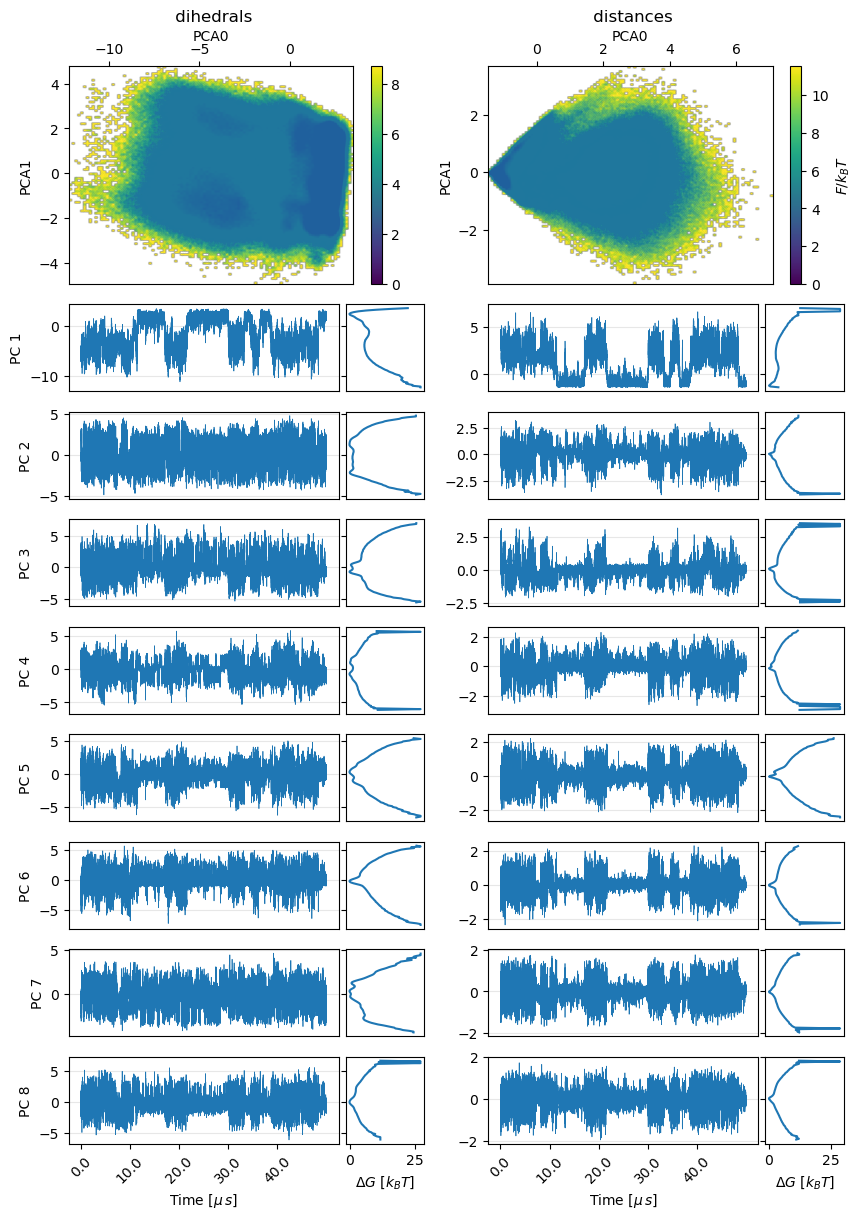

In [12]:
X_list = [dihedrals, distances]
feature_name = ["dihedrals", "distances"]
n_pcs = 8

# --------------------------------
# Plot specifics
n_microseconds_show = 50
tickevery = 10
n_show = n_microseconds_show * one_microsecond_in_frames
#

fig = plt.figure(figsize=(5* 2, 14))

gs = GridSpec(
    nrows=n_pcs + 1,
    ncols=2,
    figure=fig,
    height_ratios=[2] + [0.8] * n_pcs,
    hspace=0.2,
    wspace=0.18
)

axes = np.empty((n_pcs + 1, 2), dtype=object)

for i in range(n_pcs + 1):
    for j in range(2):
        axes[i, j] = fig.add_subplot(gs[i, j])
        

for idx, X in enumerate(X_list):
    pcamodel = PCAWrapper(dim=n_pcs)
    pcamodel.fit(X)
    pc_traj = pcamodel.transform(X)
    if idx == 1:
        colorbarlabel = r"$F/k_B T$"
    else:        
        colorbarlabel = None
    pu.plot_free_energy_projection(pc_traj, 0, 1, ax = axes[0, idx], axlabel = "PCA", colorbarlabel = colorbarlabel, axtitle = rf" {feature_name[idx]}")

    for component in range(n_pcs):

        
        ax = axes[1 + component, idx]
        x = pc_traj[:n_show, component]
        ax.set_xticks(np.arange(0, n_show, tickevery*one_microsecond_in_frames))
        ax.set_xticklabels(np.arange(0, n_show/one_microsecond_in_frames, tickevery), rotation=45)
        ax.plot(x, lw=0.5)
        if idx == 0:
            ax.set_ylabel(f"PC {component + 1}")
        else:
            ax.set_ylabel("")
        ax.tick_params(axis="x", labelrotation=45)
        ax.grid(axis="y", alpha=0.3)
        ax_fe = pu.add_1d_free_energy_axis(
            ax=ax,
            x=pc_traj[:, component], #all trajectory for free energy
            bins=100,
            color="C0")
        if component < n_pcs - 1:
            ax.set_xticks([])
            ax.set_xlabel("")
            ax_fe.set_xticks([])

        else:
            ax.set_xlabel(r"Time [$\mu\, s$]")
            ax_fe.set_xlabel(r"$\Delta G$ [$k_B T$]")

### Performing dim. reduction with the selected hyperparams 

In [14]:
tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 7

# set 1: distances
tica_model = TICA(lagtime = tica_lag, dim = tica_dim_distances).fit(distances)
tica_distances = tica_model.transform(distances)
pca_distances = PCA(n_components = pca_dim_distances).fit_transform(distances)

# set 2: dihedrals
tica_model = TICA(lagtime = tica_lag, dim = tica_dim_dihedrals).fit(dihedrals)
tica_dihedrals = tica_model.transform(dihedrals)
pca_dihedrals = PCA(n_components = pca_dim_dihedrals).fit_transform(dihedrals)

# save the TICA and PCA features for later use
np.save(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy", tica_dihedrals)
np.save(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy", pca_dihedrals)
np.save(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy", tica_distances)
np.save(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy", pca_distances)

---
---
## VAMP2 score for feature set selection: contacts only vs dihedrals only vs both

In [ ]:
from deeptime.decomposition import VAMP, vamp_score_cv

In [70]:
aggregated_traj = np.concatenate([distances, dihedrals], axis=1)

In [71]:
def make_fit_fetch(dim, lagtime):
    def fit_fetch(trajs):
        vamp = VAMP(dim=dim, lagtime=lagtime)
        vamp.fit(trajs)
        return vamp.fetch_model()
    return fit_fetch


trajs = [[distances], [dihedrals], [aggregated_traj]]  # your raw feature trajectories
traj_names = ["distances", "dihedrals", "aggregated_traj"]
results = {}

for n_vamp in [2,  4, 6,  8,  10]:
    for lagtime in [100, 1000]:
        print(f"Evaluating lagtime = {lagtime}...")
        for i,traj in enumerate(trajs):
            fit_fetch = make_fit_fetch(n_vamp, lagtime)
            scores = vamp_score_cv(fit_fetch, trajs=traj, blocksize=lagtime, n=5, r=2)
            results[(traj_names[i], n_vamp, lagtime)] = scores.mean()
            print(f"features: {traj_names[i]}, dim: {n_vamp}, lagtime={lagtime}: VAMP-2 = {scores.mean():.4f} ± {scores.std():.4f}")

Evaluating lagtime = 100...
features: distances, dim: 2, lagtime=100: VAMP-2 = 2.5449 ± 0.0071
features: dihedrals, dim: 2, lagtime=100: VAMP-2 = 2.7394 ± 0.0067
features: aggregated_traj, dim: 2, lagtime=100: VAMP-2 = 2.7917 ± 0.0052
Evaluating lagtime = 1000...
features: distances, dim: 2, lagtime=1000: VAMP-2 = 1.8936 ± 0.0161
features: dihedrals, dim: 2, lagtime=1000: VAMP-2 = 2.0842 ± 0.0452
features: aggregated_traj, dim: 2, lagtime=1000: VAMP-2 = 2.1055 ± 0.0658
Evaluating lagtime = 100...
features: distances, dim: 4, lagtime=100: VAMP-2 = 3.2965 ± 0.0135
features: dihedrals, dim: 4, lagtime=100: VAMP-2 = 4.1149 ± 0.0068
features: aggregated_traj, dim: 4, lagtime=100: VAMP-2 = 4.2063 ± 0.0103
Evaluating lagtime = 1000...
features: distances, dim: 4, lagtime=1000: VAMP-2 = 1.9798 ± 0.0302
features: dihedrals, dim: 4, lagtime=1000: VAMP-2 = 2.3159 ± 0.0523
features: aggregated_traj, dim: 4, lagtime=1000: VAMP-2 = 2.4774 ± 0.0504
Evaluating lagtime = 100...
features: distances, dim

In [73]:
import pandas as pd

rows = []

for (feature, n_vamp, lag), score in results.items():
    rows.append({
        "feature": feature,
        "n_vamp": n_vamp,
        "lag_frames": lag,
        "score": score,
    })

df = pd.DataFrame(rows)

df.to_csv("intermediate_outputs/vamp_feature_selection.csv", index=False)
df.head()

,feature,n_vamp,lag_frames,score
0,distances,2,100,2.544873
1,dihedrals,2,100,2.739389
2,aggregated_traj,2,100,2.791698
3,distances,2,1000,1.893650
4,dihedrals,2,1000,2.084234


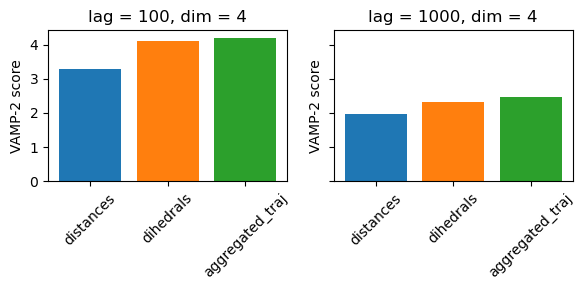

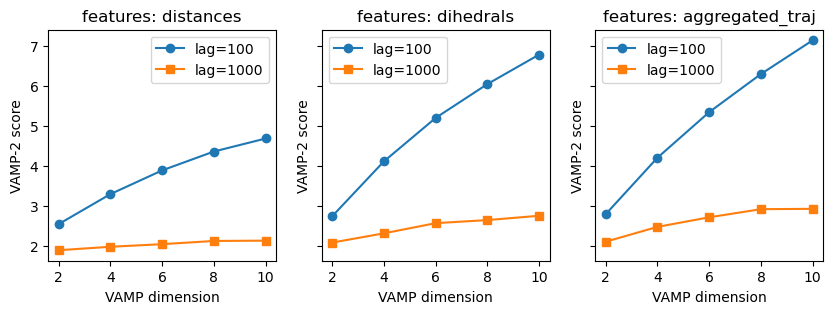

In [83]:
# Bar plot at fixed lag time, dimension


fig, axes = plt.subplots(1, len([100, 1000]), figsize=(6, 3), sharey=True)

colors = cm.tab10.colors
for ax, lag in zip(axes.flatten(), [100, 1000]):

    scores = [results[(feature, 4, lag)] for feature in traj_names]
    ax.bar(traj_names, scores, color=colors[:len(traj_names)])
    ax.set_title(f"lag = {lag}, dim = 4")
    ax.set_ylabel("VAMP-2 score")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()


# Plot as a function of dimension, varying lag time, fixed feauture set
fig, axes = plt.subplots(1, len(traj_names), figsize=(10, 3), sharey=True)
for ax, feature in zip(axes.flatten(), traj_names):

    scores_100 = [results[(feature, n_vamp, 100)] for n_vamp in [2, 4, 6, 8, 10]]
    scores_1000 = [results[(feature, n_vamp, 1000)] for n_vamp in [2, 4, 6, 8, 10]]

    ax.plot([2, 4, 6, 8, 10], scores_100, marker = "o", label="lag=100")
    ax.plot([2, 4, 6, 8, 10], scores_1000, marker = "s", label="lag=1000")
    ax.set_title(f"features: {feature}")
    ax.set_xlabel("VAMP dimension")
    ax.set_ylabel("VAMP-2 score")
    ax.legend()

In [88]:
# More in-depth analysis for dihedrals only, varying lag time and dimension.


trajs = [[dihedrals]]  # your raw feature trajectories
traj_names = ["dihedrals"]
results = {}

for n_vamp in [2, 3, 4, 5, 6, 7, 8,  9, 10]:
    for lagtime in [100, 500, 1000]:
        print(f"Evaluating lagtime = {lagtime}...")
        for i,traj in enumerate(trajs):
            fit_fetch = make_fit_fetch(n_vamp, lagtime)
            scores = vamp_score_cv(fit_fetch, trajs=traj, blocksize=lagtime, n=5, r=2)
            results[(n_vamp, lagtime)] = (scores.mean(), scores.std())
            print(f" dim: {n_vamp}, lagtime={lagtime}: VAMP-2 = {scores.mean():.4f} ± {scores.std():.4f}")





rows = []

for (n_vamp, lag), score in results.items():
    rows.append({
        "n_vamp": n_vamp,
        "lag_frames": lag,
        "score": score[0],
        "std": score[1]
    })

df = pd.DataFrame(rows)

df.to_csv("intermediate_outputs/vamp_feature_selection_dihedrals_only.csv", index=False)
df.head()

Evaluating lagtime = 100...
 dim: 2, lagtime=100: VAMP-2 = 2.7457 ± 0.0062
Evaluating lagtime = 500...
 dim: 2, lagtime=500: VAMP-2 = 2.3891 ± 0.0204
Evaluating lagtime = 1000...
 dim: 2, lagtime=1000: VAMP-2 = 2.0766 ± 0.0270
Evaluating lagtime = 100...
 dim: 3, lagtime=100: VAMP-2 = 3.4760 ± 0.0088
Evaluating lagtime = 500...
 dim: 3, lagtime=500: VAMP-2 = 2.7328 ± 0.0355
Evaluating lagtime = 1000...
 dim: 3, lagtime=1000: VAMP-2 = 2.2309 ± 0.0310
Evaluating lagtime = 100...
 dim: 4, lagtime=100: VAMP-2 = 4.1143 ± 0.0075
Evaluating lagtime = 500...
 dim: 4, lagtime=500: VAMP-2 = 3.0776 ± 0.0377
Evaluating lagtime = 1000...
 dim: 4, lagtime=1000: VAMP-2 = 2.2684 ± 0.0487
Evaluating lagtime = 100...
 dim: 5, lagtime=100: VAMP-2 = 4.6942 ± 0.0363
Evaluating lagtime = 500...
 dim: 5, lagtime=500: VAMP-2 = 3.2799 ± 0.0202
Evaluating lagtime = 1000...
 dim: 5, lagtime=1000: VAMP-2 = 2.5039 ± 0.0401
Evaluating lagtime = 100...
 dim: 6, lagtime=100: VAMP-2 = 5.1664 ± 0.0120
Evaluating lagtim

,n_vamp,lag_frames,score,std
0,2,100,2.745745,0.006162
1,2,500,2.389104,0.020402
2,2,1000,2.076589,0.026969
3,3,100,3.475969,0.008798
4,3,500,2.732816,0.035461


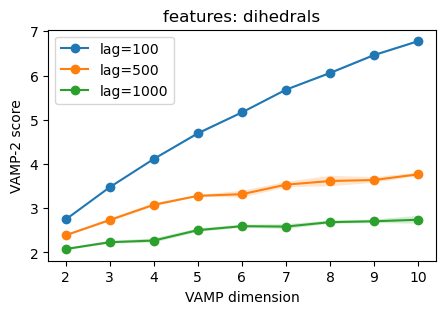

In [89]:
fig, ax = plt.subplots(1, figsize=(5, 3), sharey=True)

for lag in df["lag_frames"].unique():
    temp = df[df["lag_frames"] == lag]
    mean = temp["score"]

    ax.plot(temp["n_vamp"], temp["score"], marker = "o", label=f"lag={lag}")
    ax.fill_between(temp["n_vamp"], temp["score"] - temp["std"], temp["score"] + temp["std"], alpha=0.2)

ax.set_title(f"features: dihedrals")
ax.set_xlabel("VAMP dimension")
ax.set_ylabel("VAMP-2 score")
ax.legend()